### Import Libraries

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from importlib import import_module, reload
import numpy as np
import geopandas as gpd
# import mapclassify
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D 
from matplotlib import cm
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap
from shapely.geometry import Polygon
%matplotlib notebook

### SQL Connection

In [16]:
# from sql_queries import queries, sql_exposureSetSID
sql_queries = import_module("sql_queries")
reload(sql_queries)
# queries = getattr(sql_queries, "queries")
# sql_exposureSetSID = getattr(sql_queries, "sql_exposureSetSID")

us_map = getattr(sql_queries, "us_map")
# us_state_county_map = getattr(sql_queries, "us_state_county_map")

average_property_value_queries = getattr(sql_queries, "average_property_value_queries")
price_per_SQFT_queries =  getattr(sql_queries, "price_per_SQFT_queries")
secondary_modifiers_queries =  getattr(sql_queries, "secondary_modifiers_queries")

from db_connection import get_engine

In [17]:
## SQL Connection Inputs

db_v10_config = dict(
DRIVER_NAME = "{SQL Server}",
SERVER_NAME = "clv235dw-bbee4d",
DB_NAME = "AIRProject",
USERNAME = "ARAPL_USR",
PASSWORD = "Arapl@123"
)

## Trigger the SQL Connection
engine = get_engine(**db_v10_config)

In [18]:
## Query Inputs

## Inputs for Industry State and County Level
state_query_params={"Loc_Filter":500}

county_query_params={"Loc_Filter":100}

## Extract DB ID from Exposure Meta Table in ARAPL_DataQuality DB
# currentYear_DbID means latest Year DB's ID from exposure meta table
# previousYear_DbID means previous Year DB's ID from exposure meta table
YoY_query_params = {"CurrentYear_DbID": 23 ,
                   "PreviousYear_DbID": 24,
                   "State_Loc_Filter": 500,
                    "County_Loc_Filter":100
                   }

secondary_modifiers = {'exposureMetaID': 137}

In [19]:
id_StatePrice_sql_code = price_per_SQFT_queries['Industry_State'].format(**state_query_params)
id_CountyPrice_sql_code = price_per_SQFT_queries['Industry_County'].format(**county_query_params)


id_StatePropValue_sql_code = average_property_value_queries['Industry_State'].format(**state_query_params)
id_CountyPropValue_sql_code = average_property_value_queries['Industry_County'].format(**county_query_params)

In [20]:
deal_YoYPrice_sql_code = price_per_SQFT_queries['Deal_YoY'].format(**YoY_query_params)
deal_YoYPropValue_sql_code = average_property_value_queries['Deal_YoY'].format(**YoY_query_params)

In [21]:
deal_RoofCover_sql_code = secondary_modifiers_queries['RoofCover'].format(**secondary_modifiers)
deal_RoofGeometry_sql_code = secondary_modifiers_queries['RoofGeometry'].format(**secondary_modifiers)
deal_RoofDeckAttachment_sql_code = secondary_modifiers_queries['RoofDeckAttachment'].format(**secondary_modifiers)
deal_RoofAge_sql_code = secondary_modifiers_queries['RoofAge'].format(**secondary_modifiers)
deal_RoofWindowProtection_sql_code = secondary_modifiers_queries['RoofWindowProtection'].format(**secondary_modifiers)

In [22]:
### Deal's DataFrame

## Price Per SQFT with YoY Data
deal_YoYPrice_df = pd.read_sql_query(deal_YoYPrice_sql_code, con=engine)

## Average Property Value with YoY Data
deal_YoYPropValue_df = pd.read_sql_query(deal_YoYPropValue_sql_code, con=engine)


### Industry DataFrame

## Price Per SQFT
id_StatePrice_df = pd.read_sql_query(id_StatePrice_sql_code, con=engine)
id_CountyPrice_df = pd.read_sql_query(id_CountyPrice_sql_code, con=engine)

## Average Property Value
id_StatePropValue_df = pd.read_sql_query(id_StatePropValue_sql_code, con=engine)
id_CountyPropValue_df = pd.read_sql_query(id_CountyPropValue_sql_code, con=engine)


## Secondary Modifiers
deal_RoofCover_df = pd.read_sql_query(deal_RoofCover_sql_code, con=engine)
deal_RoofGeometry_df = pd.read_sql_query(deal_RoofGeometry_sql_code, con=engine)
deal_RoofDeckAttachment_df = pd.read_sql_query(deal_RoofDeckAttachment_sql_code, con=engine)
deal_RoofAge_df = pd.read_sql_query(deal_RoofAge_sql_code, con=engine)
deal_RoofWindowProtection_df = pd.read_sql_query(deal_RoofWindowProtection_sql_code, con=engine)


In [23]:

## read data from sql query to dataframe
us_df = pd.read_sql_query(us_map, con=engine)

us_df = us_df[us_df['StateCode']!= 'AK'][us_df['StateCode']!='HI']
## extract the state data
us_state_df = us_df[us_df['County'].isnull()]

## extract the county data
us_state_county_df = us_df[~us_df['County'].isnull()]

## Convert Pandas DataFrame to GeoPandas DataFrame to plot
us_state_df['geometry'] = gpd.GeoSeries.from_wkt(us_state_df['geometry'])
us_state_df = gpd.GeoDataFrame(us_state_df, geometry='geometry')

us_state_county_df['geometry'] = gpd.GeoSeries.from_wkt(us_state_county_df['geometry'])
us_state_county_df = gpd.GeoDataFrame(us_state_county_df, geometry='geometry')


C:\pithon.shared\prod3\1.209.0\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  after removing the cwd from sys.path.
C:\pithon.shared\prod3\1.209.0\lib\site-packages\ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':
C:\pithon.shared\prod3\1.209.0\lib\site-packages\ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app


## Secondary Modifiers

In [24]:
deal_RoofCover_df['TIV_Pct'] = deal_RoofCover_df['TIV'] / deal_RoofCover_df['TotalTIV']
deal_RoofCover_df['LocationCount_Pct'] = deal_RoofCover_df['LocCount'] / deal_RoofCover_df['TotalLocCount']
deal_RoofCover_df['ContractCount_Pct'] = deal_RoofCover_df['ConCount'] / deal_RoofCover_df['TotalConCount']

grp_RoofCover = deal_RoofCover_df.groupby(by='RoofCover').sum()[['TIV_Pct','LocationCount_Pct', 'ContractCount_Pct']]
grp_RoofCover.head()

,TIV_Pct,LocationCount_Pct,ContractCount_Pct
RoofCover,,,
Asphalt shingles,0.062052,0.051981,0.051981
Hurricane Wind-Rated Roof Coverings,0.912198,0.911043,0.911043
Unknown/default,0.025750,0.036976,0.036976


<IPython.core.display.Javascript object>


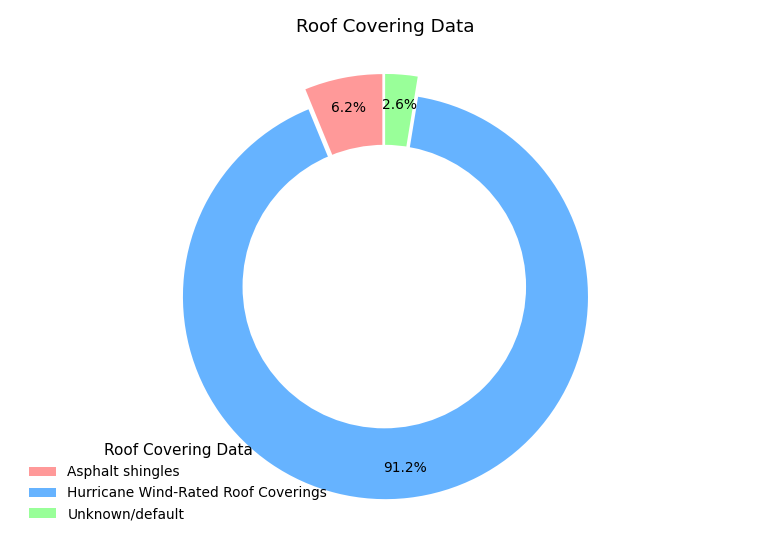

C:\pithon.shared\prod3\1.209.0\lib\site-packages\ipykernel_launcher.py:18: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 


In [25]:
#explsion
explode = (0.05,0.05,0.05) #,0.05)

#colors
colors = ['#ff9999','#66b3ff','#99ff99'] #,'#ffcc99']

sizes = grp_RoofCover['TIV_Pct']

labels = grp_RoofCover.index.tolist()

legend_title = 'Roof Cover Types'
title = 'Roof Covering Data'
 
fig1, ax1 = plt.subplots(figsize=(7,5))

fig1.subplots_adjust(left=0.3, right=0.8, wspace=1)
ax1.pie(sizes, colors = colors, autopct='%1.1f%%', startangle=90, wedgeprops = { 'linewidth' : 7}#, 'edgecolor' : 'white' }
       , pctdistance= 0.85, explode = explode, textprops={'fontsize': 9})
legend = ax1.legend(labels, loc="lower left", 
                    prop={'size':9}, 
                    frameon = True,
                    framealpha = 0
          ,title = title
          ,title_fontsize=10
              )
# legend.set_title(title = 'Roof Cover Types', )
#draw circle
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Equal aspect ratio ensures that pie is drawn as a circle
plt.title(title)
ax1.axis('equal')

plt.tight_layout()
plt.show()

In [43]:
roofCoverFLPen = "C:\\Users\\tpatel2\\Documents\\RoofCover FL Pen v2.csv"

In [135]:
df = pd.read_csv(roofCoverFLPen, sep='\t')
df = df.dropna(subset = ['State'])
# df.head()
df['geometry'] = gpd.GeoSeries.from_wkt(df['geometry'])

gdf = gpd.GeoDataFrame(df, geometry='geometry')

gdf['total_CountyTIVPct'] = gdf['County_TIV'] / gdf['state_TIV']

gdf['total_roofcoverCountyTIVPct'] = gdf['TIV'] / gdf['County_TIV']

gdf = gdf[['COunty', 'RoofCover', 'total_roofcoverCountyTIVPct', 'total_CountyTIVPct', 'geometry']]

CountyGeo = gdf[['COunty', 'geometry']].drop_duplicates()

gdf.head()

,COunty,RoofCover,total_roofcoverCountyTIVPct,total_CountyTIVPct,geometry
0,Alachua,Asphalt shingles,0.031270,0.001401,"POLYGON ((-82.29830 29.40970, -82.32100 29.424..."
1,Alachua,Hurricane Wind-Rated Roof Coverings,0.753808,0.001401,"POLYGON ((-82.29830 29.40970, -82.32100 29.424..."
2,Alachua,Unknown/default,0.214922,0.001401,"POLYGON ((-82.29830 29.40970, -82.32100 29.424..."
3,Baker,Hurricane Wind-Rated Roof Coverings,0.624910,0.000125,"POLYGON ((-82.45840 30.13640, -82.45820 30.201..."
4,Baker,Unknown/default,0.375090,0.000125,"POLYGON ((-82.45840 30.13640, -82.45820 30.201..."


In [136]:
pen_counties = set({})

for index, row in gdf.iterrows():
    
    if row['geometry'].centroid.coords[0][0] < -84.094:
        pen_counties.add(row['COunty'])
#         print(row['COunty'])

pen_counties = list(pen_counties)
print(len(pen_counties))

15


In [137]:
gdf = gdf[~gdf['COunty'].isin(pen_counties)]
gdf

,COunty,RoofCover,total_roofcoverCountyTIVPct,total_CountyTIVPct,geometry
0,Alachua,Asphalt shingles,0.031270,0.001401,"POLYGON ((-82.29830 29.40970, -82.32100 29.424..."
1,Alachua,Hurricane Wind-Rated Roof Coverings,0.753808,0.001401,"POLYGON ((-82.29830 29.40970, -82.32100 29.424..."
2,Alachua,Unknown/default,0.214922,0.001401,"POLYGON ((-82.29830 29.40970, -82.32100 29.424..."
3,Baker,Hurricane Wind-Rated Roof Coverings,0.624910,0.000125,"POLYGON ((-82.45840 30.13640, -82.45820 30.201..."
4,Baker,Unknown/default,0.375090,0.000125,"POLYGON ((-82.45840 30.13640, -82.45820 30.201..."
...,...,...,...,...,...
340,Union,Hurricane Wind-Rated Roof Coverings,0.393440,0.000039,"POLYGON ((-82.42640 29.92090, -82.43900 29.931..."
341,Union,Unknown/default,0.606560,0.000039,"POLYGON ((-82.42640 29.92090, -82.43900 29.931..."
342,Volusia,Asphalt shingles,0.029561,0.024165,"MULTIPOLYGON (((-80.87756 28.98751, -80.87680 ..."
343,Volusia,Hurricane Wind-Rated Roof Coverings,0.885841,0.024165,"MULTIPOLYGON (((-80.87756 28.98751, -80.87680 ..."


<IPython.core.display.Javascript object>


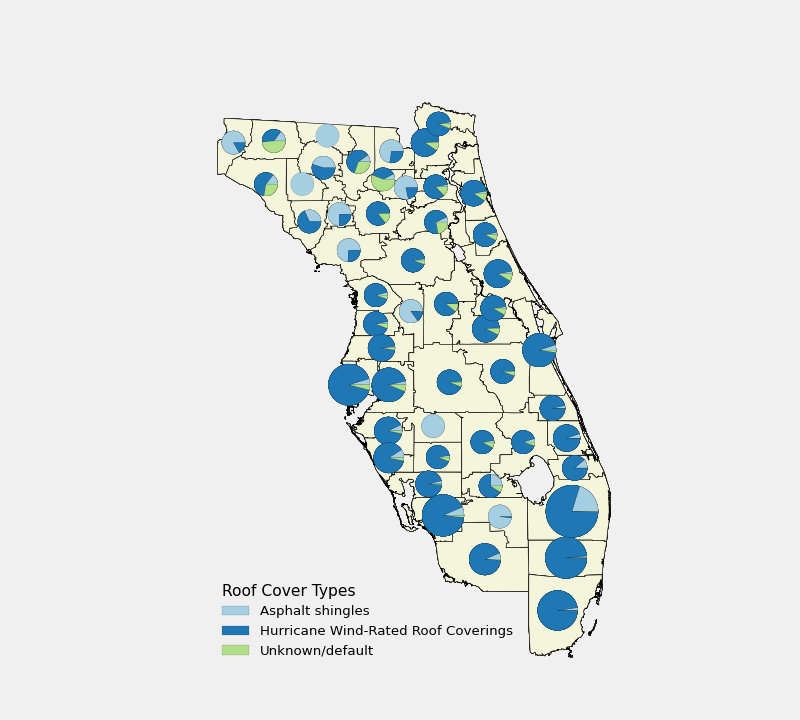

C:\pithon.shared\prod3\1.209.0\lib\site-packages\geopandas\plotting.py:642: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  "Only specify one of 'column' or 'color'. Using 'color'.", UserWarning
C:\pithon.shared\prod3\1.209.0\lib\site-packages\ipykernel_launcher.py:36: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 
C:\pithon.shared\prod3\1.209.0\lib\site-packages\ipykernel_launcher.py:68: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "frameon" which is no longer supported as of 3.3 and will become an error two minor releases later
C:\pithon.shared\prod3\1.209.0\lib\site-packages\ipykernel_launcher.py:68: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.


In [161]:
plt.style.use('fivethirtyeight')

# fig1, ax1  = plt.subplots(figsize=())
fig2, ax2  = plt.subplots(figsize=(10,9))

# ax2.set_aspect(0.5)
# ax1.set_xlim(-130, -60)
# ax1.set_ylim(24,50)
ax2.set_xlim(-83.8, -79)
ax2.set_ylim(24,31)
# ax2.set_xlim(-88,-83.8)
# ax2.set_ylim(29.55,31)
cmap = plt.get_cmap('Spectral')
colors = [cmap(i) for  i in np.linspace(0,1,10)]

colors = sns.color_palette('Paired')

labels = gdf.RoofCover.unique().tolist()

# gdf_state.plot(ax=ax2, color = 'Beige', edgecolor ='black', label = 'me',  column = 'roofGeometry', zorder=-1000)
gdf.plot(ax=ax2, color= 'Beige', edgecolor ='black', label = 'me',  column = 'RoofCover', zorder=-1000)
# fig1.tight_layout()
# print("base map", ax.get_ylim(), ax.get_xlim())

# for name, County in CountyGeo.iterrows():
#     plt.annotate(County['COunty'], xy= County['geometry'].centroid.coords[0], ha='center', fontsize=7)


for index, row in gdf.iterrows():
    
    county_name = row['COunty']
    value_dict = dict(zip(gdf.loc[df['COunty'] == county_name]['RoofCover'], gdf.loc[gdf['COunty'] == county_name]['total_roofcoverCountyTIVPct']))
#     print(value_dict)
    radius = (0.12 + 1* gdf.loc[gdf['COunty'] == county_name]['total_CountyTIVPct'].iloc[0])
    
    pie = ax2.pie(value_dict.values(), radius = radius, colors = colors, center = row['geometry'].centroid.coords[0], frame=True, wedgeprops = {'edgecolor' : 'k', 'linewidth': 0.1})  
    # wedgeprops={"figure": fig2}
    # print("pie", index, ax.get_ylim(), ax.get_xlim())
#     print(patches)
#     ax2.annotate(state_name, xy=row['geometry'].centroid.coords[0],ha = 'left', va='baseline')#, va='center')
#     print(state_name)
    
    if len(value_dict.values()) == len(labels):
        leg = ax2.legend(pie[0],labels, fontsize=12, frameon = False, title='Roof Cover Types',
                   title_fontsize = 'medium')
#                   alignment = 'left')
        leg._legend_box.align = 'left'
    else:
        pass
 
# plt.title(label= 'Roof Cover across Florida State')

ax2.set_xlabel('')
# for major ticks
ax2.set_xticks([])
# for minor ticks
ax2.set_xticks([], minor=True)
ax2.set_ylabel('')
# for major ticks
ax2.set_yticks([])
# for minor ticks
ax2.set_yticks([], minor=True)

# ax2.set_aspect(0.5)
ax2.axis([-84.15, -80, 25,31])

fig2.show()
fig2.savefig(r"Y:\Code\Data Quality\FLPen_PenHandle_RoofCover.png", transparent=True, format="png", frameon=False)

In [38]:
roofCoverFile = "Y:\\Code\\Data Quality\\Data Files\\roofCoverData_2023Apex_2.csv"
roofGeometryFile = "Y:\\Code\\Data Quality\\Data Files\\roofGeometryData_2023Apex_2.csv"
rfgeo_df = pd.read_csv(roofGeometryFile, sep='\t')


rfcover_df = pd.read_csv(roofCoverFile, sep='\t')

rfcover_df[['state', 'geometry']].head(10)


,state,geometry
0,Alabama,POLYGON ((-88.028299999999888 30.2226999999999...
1,Alabama,"POLYGON ((-85.588 32.6267, -85.5946 32.6366, -..."
2,Alabama,"POLYGON ((-86.8319 30.9974, -86.846 31.0042, -..."
3,Alabama,"POLYGON ((-86.9958 33.2187, -87.0259 33.221, -..."
4,Alabama,"POLYGON ((-86.9958 33.2187, -87.0259 33.221, -..."
5,Alabama,"POLYGON ((-86.9958 33.2187, -87.0259 33.221, -..."
6,Alabama,MULTIPOLYGON (((-88.020293479248551 30.6811782...
7,Alabama,MULTIPOLYGON (((-88.020293479248551 30.6811782...
8,Alabama,MULTIPOLYGON (((-88.020293479248551 30.6811782...
9,Alaska,"POLYGON ((-146.942 61.4902, -147.213 61.455, -..."


In [27]:
rfgeo_df = rfcover_df

## rename attribute column 
rfgeo_df = rfgeo_df.rename({'roofcover':'roofGeometry'}, axis =1 )

rfgeo_df = rfgeo_df.dropna(subset = ['Perilcode'])

rfgeo_df['geometry'] = gpd.GeoSeries.from_wkt(rfgeo_df['geometry'])

gdf = gpd.GeoDataFrame(rfgeo_df, geometry='geometry')

stateDf =  rfgeo_df[rfgeo_df['county'].isna()]

stategeo = rfgeo_df[rfgeo_df['county'].isna()][['state', 'geometry']].drop_duplicates()


#### To Do.2

1. Drop the exposureMetaID and PerilCode columns from df
2. Find the total TIV of exposureset
3. Find the state wise Total TIV percentage of exposure
4. Based on state wise splited Total TIV percent, future split that percetage amoung different roofGeometry
5. Create Pie chart for one state
6. Based Statewise share of TIV, resize the Pie Chart
7. Create multiple Pie charts for all states and resized it based on corresponding states TIV share
8. Create US Map
9. Plot one Pie Chart on top of state
10. find out the centroids of each states
11. Similarly Plot all the Pie Chart on top of US Map based on it's correspoding state


In [28]:
# Drop the exposureMetaID and PerilCode columns from df

df = stateDf 

df = df.drop(['exposureMetID', 'Perilcode'], axis=1)

df = df.groupby(by=['state', 'roofGeometry']).sum()

df['TotalTIV'] = df['TIV'] / df['totalTIVPct']

df = df.reset_index()

state_total = df.groupby(by = ['state']).sum()['TIV']

state_total = state_total.rename('state_TIV')

df = df.merge(state_total, on='state', how='left') #, left_index= True)

df['total_stateTIVPct'] = df['state_TIV'] / df['TotalTIV']

df['total_roofgeoStateTIVPct'] = df['TIV'] / df['state_TIV']

df = df.merge(stategeo, on=['state'], how='left')

gdf_state = gpd.GeoDataFrame(df, geometry='geometry')

gdf_state = gdf_state[['state', 'roofGeometry', 'total_roofgeoStateTIVPct', 'total_stateTIVPct', 'geometry']]

stateGeo = gdf_state[['state', 'geometry']].drop_duplicates()



<IPython.core.display.Javascript object>


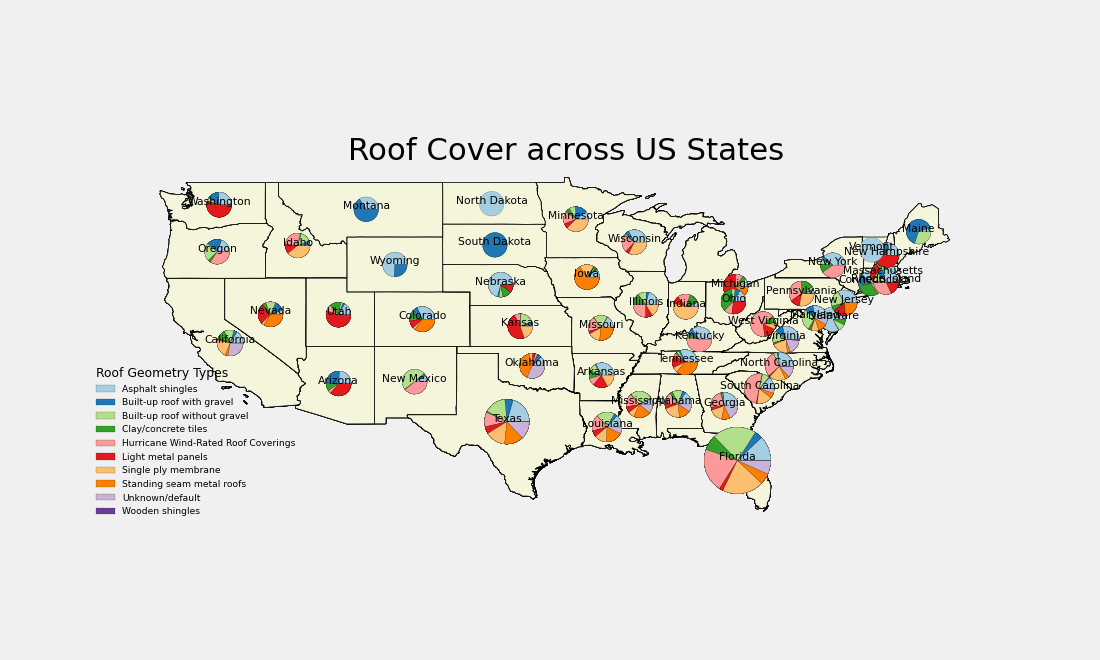

C:\pithon.shared\prod3\1.209.0\lib\site-packages\geopandas\plotting.py:642: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  "Only specify one of 'column' or 'color'. Using 'color'.", UserWarning
C:\pithon.shared\prod3\1.209.0\lib\site-packages\ipykernel_launcher.py:36: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 


In [29]:
plt.style.use('fivethirtyeight')

# fig1, ax1  = plt.subplots(figsize=())
fig2, ax2  = plt.subplots(figsize=(10,6))

# ax1.set_xlim(-130, -60)
# ax1.set_ylim(24,50)
ax2.set_xlim(-130, -60)
ax2.set_ylim(24,50)
cmap = plt.get_cmap('Spectral')
colors = [cmap(i) for  i in np.linspace(0,1,10)]

colors = sns.color_palette('Paired')

labels = gdf_state.roofGeometry.unique().tolist()

# gdf_state.plot(ax=ax2, color = 'Beige', edgecolor ='black', label = 'me',  column = 'roofGeometry', zorder=-1000)
gdf_state.plot(ax=ax2, color= 'Beige', edgecolor ='black', label = 'me',  column = 'roofGeometry', zorder=-1000)
# fig1.tight_layout()
# print("base map", ax.get_ylim(), ax.get_xlim())

for name, state in stateGeo.iterrows():
    plt.annotate(state['state'], xy= state['geometry'].centroid.coords[0], ha='center', fontsize=7)



for index, row in gdf_state.iterrows():
    
    state_name = row['state']
    value_dict = dict(zip(df.loc[df['state'] == state_name]['roofGeometry'], df.loc[df['state'] == state_name]['total_roofgeoStateTIVPct']))
#     print(value_dict)
    radius = (0.9 + 20* df.loc[df['state'] == state_name]['total_stateTIVPct'].iloc[0])
    
    pie = ax2.pie(value_dict.values(), radius = radius, colors = colors, center = row['geometry'].centroid.coords[0], frame=True, wedgeprops = {'edgecolor' : 'k', 'linewidth': 0.1})  
    # wedgeprops={"figure": fig2}
    # print("pie", index, ax.get_ylim(), ax.get_xlim())
#     print(patches)
#     ax2.annotate(state_name, xy=row['geometry'].centroid.coords[0],ha = 'left', va='baseline')#, va='center')
#     print(state_name)
    
    if len(value_dict.values()) == len(labels):
        leg = ax2.legend(pie[0],labels, loc=3, fontsize=6, frameon = False, title='Roof Geometry Types',
                   title_fontsize = 'xx-small')
#                   alignment = 'left')
        leg._legend_box.align = 'left'
    else:
        pass
 
plt.title(label= 'Roof Cover across US States')

ax2.set_xlabel('')
# for major ticks
ax2.set_xticks([])
# for minor ticks
ax2.set_xticks([], minor=True)
ax2.set_ylabel('')
# for major ticks
ax2.set_yticks([])
# for minor ticks
ax2.set_yticks([], minor=True)


#     if index > 6:
#         break
#     x, y = row.geometry.exterior.coords.xy
#     ax.plot(x, y)
# fig1.savefig(r"Y:\Code\Data Quality\map.png", transparent=True, format="png")
# fig2.savefig(r"Y:\Code\Data Quality\pies.png", transparent=True, format="png")


fig2.show()
# fig2.savefig(r"Y:\Code\Data Quality\Roof Geometry Pies.png", transparent=True, format="png")

## Functions

In [30]:
def percentile_flag(dataList, value):
    
    # more 75 percentile return 1
    if value > np.percentile(dataList, 75):
        return 1
    # below 25 percentile return -1
    elif value < np.percentile(dataList, 25):
        return -1
    # between 25 and 75 percentile return 0
    else:
        return 0


In [31]:

# def plt_function(dataset, valueColumn, State_or_County, Percentage_Flag, colorbar_label,
#                  textstr, textstr_title, title, tfont, vmin, vmax):
    
#     """"""
#     plt.style.use('fivethirtyeight')
    
#     ## Colorbar scale's minimum and maximum value
#     ## vmin = Value Minimum
#     vmin = vmin
    
#     ## vmax = Value Maximum
#     vmax = vmax
    
#     ## Define the plots
#     fig, ax = plt.subplots(figsize=(10,6))
    
#     ## Set limitation on both axes
#     ax.set_xlim(-130, -60)
#     ax.set_ylim(24, 50)
    
#     fig.subplots_adjust(left=0.3, right=0.8)
#     # define cmap
#     cmap =  LinearSegmentedColormap.from_list("", ["blue","green","red"])
    
#     ## based on State_or_County value, plot statewise initial map which will show boundaries of each state
#     if State_or_County == "State":
#         US_State_Shapes = "Y://Code//Data Quality//Data Files//US State Shapes.csv"
#         US_State_df = pd.read_csv(US_State_Shapes, sep='\t')
#         US_State_df = US_State_df.dropna(subset=['geometry'])
#         US_State_df['geometry'] = gpd.GeoSeries.from_wkt(US_State_df['geometry'])
#         US_State_gdf = gpd.GeoDataFrame(US_State_df, geometry='geometry')
        
#         ## Plot US Map
#         US_State_gdf.plot(ax=ax, color='white', edgecolor='k')
        
#     elif State_or_County == "County":
#         US_State_Shapes = "Y://Code//Data Quality//Data Files//US State Shapes.csv"
#         US_State_df = pd.read_csv(US_State_Shapes, sep='\t')
#         US_State_df = US_State_df.dropna(subset=['geometry'])
#         US_State_df['geometry'] = gpd.GeoSeries.from_wkt(US_State_df['geometry'])
#         US_State_gdf = gpd.GeoDataFrame(US_State_df, geometry='geometry')
        
#         ## Plot US Map
#         US_State_gdf.plot(ax=ax, color='white', edgecolor='k')
        
# #         US_State_County_Shapes = "Y://Code//Data Quality//Data Files//US State County Shapes.csv"
# #         US_State_County_df = pd.read_csv(US_State_County_Shapes, sep='\t')
# #         US_State_County_df = US_State_County_df.dropna(subset=['geometry'])
# #         US_State_County_df['geometry'] = gpd.GeoSeries.from_wkt(US_State_County_df['geometry'])
# #         US_State_County_gdf = gpd.GeoDataFrame(US_State_County_df, geometry='geometry')
        
# #         ## Plot US Map
# #         US_State_County_gdf.plot(ax=ax, color='white', edgecolor='k')
        
    
#     if Percentage_Flag:
        
#         morethan75 = dataset[dataset['Percentile_Flag'] == 1]
#         morethan75.plot(column=valueColumn, 
#                    ax=ax, edgecolor= 'k',
#                    cmap=cmap, 
#                    legend=False ,
#                    vmin=vmin,
#                    vmax=vmax,
#                   zorder=1)


#         morethan75.plot(column=valueColumn, 
#                    ax=ax, hatch = '///', 
#                    cmap=cmap, 
#                    legend=False ,
#                    vmin=vmin,
#                    vmax=vmax,
#                   zorder=100) #, c=colors, cmap='viridis')


#         below25 = dataset[dataset['Percentile_Flag'] == -1]

#         below25.plot(column=valueColumn,
#                      ax=ax,
#                      edgecolor= 'k',
#                      cmap=cmap ,
#                      vmin=vmin,
#                      vmax=vmax,
#                     zorder=2)
#         below25.plot(column=valueColumn,
#                      ax=ax,
#                      hatch="..",
#                      cmap=cmap ,
#                      vmin=vmin,
#                      vmax=vmax,
#                     zorder=100)


#         inRange = dataset[dataset['Percentile_Flag'] == 0]
#         inRange.plot(column=valueColumn, 
#                      ax=ax,
#                      cmap=cmap,
#                      legend=False ,
#                      vmin=vmin, 
#                      vmax=vmax, 
#                      edgecolor='k')
#     else: 
#         dataset.plot(column=valueColumn, 
#                    ax=ax, edgecolor= 'k',
#                    cmap=cmap, 
#                    legend=False ,
#                    vmin=vmin,
#                    vmax=vmax, zorder=1)

#         dataset.plot(column=valueColumn, 
#                    ax=ax,
#                    hatch = hatch,
#                    cmap=cmap, 
#                    legend=False ,
#                    vmin=vmin,
#                    vmax=vmax, zorder=100)
        
    
#     norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
                
#     cbar = plt.colorbar(mappable=cm.ScalarMappable(norm=norm,
#                          cmap=cmap),
#                         ax=ax,
#                         shrink=0.68,
#                         pad=1e-100)
    
#     cbar.set_label(colorbar_label, fontsize=13)
# #     cbar.ax.set_yticks(['-5%', '-3%', '0%', '3%', '5%'])
    
#     plt.title(label= title, fontsize=tfont)
    
#     ## Text Box
#     props = dict(boxstyle='round', color= 'white', alpha=0.5)
#     props_title = dict(boxstyle='round', color= 'white', alpha=0.6)

#     # place a text box in upper left in axes coords
#     ax.text(0, 0, textstr, transform=ax.transAxes, fontsize=7,
#             bbox=props, verticalalignment ='baseline',
#             horizontalalignment ='left')

#     ax.text(0, 0.13, textstr_title, transform=ax.transAxes, fontsize=6, verticalalignment ='baseline', bbox = props_title,
#             horizontalalignment ='left', weight='bold')
    
#     ## Remove unnecessary Boarders
#     ax.spines['right'].set_visible(False)
#     ax.spines['top'].set_visible(False)
#     ax.spines['left'].set_visible(False)
#     ax.spines['bottom'].set_visible(False)
#     ax.set_xlabel('')
#     # or major ticks
#     ax.set_xticks([])
#     # for minor ticks
#     ax.set_xticks([], minor=True)
#     ax.set_ylabel('')
#     # for major ticks
#     ax.set_yticks([])
#     # for minor ticks
#     ax.set_yticks([], minor=True)

#     fig.tight_layout()
    
#     fig.show()
     

In [32]:

def plotFunction(dataset, valueColumn, graph_gdf, state=None, county=None, BenchmarkFlag=False, cmap=None, **plot_inputs):
    
    """"""
    plt.style.use('fivethirtyeight')
    
    if state is not None:
        print('state is not None')
        dataset = dataset[dataset['State'] == state]
        graph_gdf1 = graph_gdf[graph_gdf['State'] == state]
    
    if county is not None:
        print('county is not None')
        dataset = dataset[dataset['County'] == county]
        graph_gdf1 = graph_gdf[graph_gdf['County'] == county]
        
       
    ## Colorbar scale's minimum and maximum value
    ## vmin = Value Minimum
    vmin = plot_inputs['vmin']
    
    ## vmax = Value Maximum
    vmax = plot_inputs['vmax']
    
    ## Define the plots
    fig, ax = plt.subplots(figsize=(10,6))
    
    fig.subplots_adjust(left=0.3, right=0.8)
    
    ## Set limitation on both axes
    if state is None and county is None:
        print('state is None')
        ax.set_xlim(-130, -60)
        ax.set_ylim(24, 50)
    else: # state or county is not None:
        print('state is not None')
        lims = graph_gdf1['geometry'].iloc[0].boundary.bounds
        minx, miny, maxx, maxy = lims[0], lims[1], lims[2], lims[3]
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
            
    # define cmap
    if cmap is None:
        cmap =  LinearSegmentedColormap.from_list("", ["blue","green","reds"])
    else:
        cmap = plt.cm.get_cmap(cmap, 5)

    ## Plot US Map
    graph_gdf.plot(ax=ax, color='white', edgecolor='k')
    
        ## set labels
    if state is  None or county is not None:
        for idx, row in graph_gdf[['StateCode', 'geometry']].iterrows():
            ax.annotate(row['StateCode'], xy= row['geometry'].centroid.coords[0], ha='center', fontsize=10)
        
    
    ## Benchmarking against Industry Data by creating textlines on state
    # Percentile_Flag = 1 : data with more than 75 Percentile
    # Percentile_Flag = -1 : data with lower than 25 Percentile
    # Percentile_Flag = 0 : data between 25 and 75 Percentile
    if BenchmarkFlag:      
        morethan75 = dataset[dataset['Percentile_Flag'] == 1]
        
        ## plot the data without textlines and with boundries
        morethan75.plot(column=valueColumn, 
                   ax=ax, edgecolor= 'k',
                   cmap=cmap, 
                   legend=False ,
#                    scheme = 'EqualInterval',
                   vmin=plot_inputs['vmin'],
                   vmax=plot_inputs['vmax'],
                  zorder=1)
        
        ## plot the daat with textlines
        # while creating textlines on state, it is not plotting state edgees that is why above code
        morethan75.plot(column=valueColumn, 
                   ax=ax, hatch = '///', 
                   cmap=cmap, 
                   legend=False ,
#                         scheme = 'EqualInterval',
                   vmin=plot_inputs['vmin'],
                   vmax=plot_inputs['vmax'],
                  zorder=100) #, c=colors, cmap='viridis')


        below25 = dataset[dataset['Percentile_Flag'] == -1]

        below25.plot(column=valueColumn,
                     ax=ax,
                     edgecolor= 'k',
                     cmap=cmap ,
#                      scheme = 'EqualInterval',
                     vmin=plot_inputs['vmin'],
                   vmax=plot_inputs['vmax'],
                    zorder=2)
        below25.plot(column=valueColumn,
                     ax=ax,
                     hatch="..",
                     cmap=cmap ,
#                      scheme = 'EqualInterval',
                     vmin=plot_inputs['vmin'],
                    vmax=plot_inputs['vmax'],
                    zorder=100)


        inRange = dataset[dataset['Percentile_Flag'] == 0]
        inRange.plot(column=valueColumn, 
                     ax=ax,
                     cmap=cmap,
                     legend=False ,
#                      scheme = 'EqualInterval',
                    vmin=plot_inputs['vmin'],
                    vmax=plot_inputs['vmax'], 
                     edgecolor='k')
        
    ## No Benchmarking, just plot the data on map
    else: 
        dataset.plot(column=valueColumn, 
                   ax=ax, edgecolor= 'k',
                   cmap=cmap, 
                   legend=False ,
#                      scheme = 'EqualInterval',
                   vmin=plot_inputs['vmin'],
                   vmax=plot_inputs['vmax'],
                     zorder=1)

        dataset.plot(column=valueColumn, 
                   ax=ax,
                   hatch = hatch,
                   cmap=cmap, 
                   legend=False ,
#                      scheme = 'EqualInterval',
                   vmin=plot_inputs['vmin'],
                   vmax=plot_inputs['vmax'],
                   zorder=100)
        
    ## Colorbar     
    norm = mpl.colors.Normalize( vmin=plot_inputs['vmin'], vmax=plot_inputs['vmax'],)               
    cbar = plt.colorbar(mappable=cm.ScalarMappable(norm=norm,
                         cmap=cmap),
                        ax=ax,
                        shrink=0.5,
                        pad=1e-100,orientation = 'horizontal')
    
    cbar.set_label(plot_inputs['colorbar_label'], fontsize=10)
    
    cbar.ax.set_xticklabels(plot_inputs['colorbar_ticks'], fontsize=9)
    
    ## Title
    print(type(state), state)
    if state is not None:  
        title = state + ' State ' + str(plot_inputs['title'])
    elif county is not None:
        title = county + ' County ' + str(plot_inputs['title'])
    else:
        title = 'US All States ' + str(plot_inputs['title'])
        
    plt.title(label= title, fontsize= plot_inputs['tfont'])
    
    ## Text Box
#     props = dict(boxstyle='round', color= 'white', alpha=0.5)
#     props_title = dict(boxstyle='round', color= 'white', alpha=0.6)

    # place a text box in upper left in axes coords
#     ax.text(0, 0, plot_inputs['textstr'],
#             transform=ax.transAxes,
#             fontsize=7,
#             bbox=props, 
#             verticalalignment ='baseline',
#             horizontalalignment ='left')

#     ax.text(0, 0.13, plot_inputs['textstr_title'], 
#             transform=ax.transAxes,
#             fontsize=6, 
#             verticalalignment ='baseline',
#             bbox = props_title,
#             horizontalalignment ='left', weight='bold')
    

    
    ## Remove unnecessary Boarders
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.set_xlabel('')
    # or major ticks
    ax.set_xticks([])
    # for minor ticks
    ax.set_xticks([], minor=True)
    ax.set_ylabel('')
    # for major ticks
    ax.set_yticks([])
    # for minor ticks
    ax.set_yticks([], minor=True)

    fig.tight_layout()
    
    fig.show()
     

### Cost per SQFT
- State Level
- County Level

#### Data Pre Processing

In [356]:
# id_StatePrice_df = 

id_StatePrice_df1 = id_StatePrice_df[['Country', 'State',
       'BuildingValue', 'LocCount', 'ConCount', 'BuildingvalueperSQFT',
       'FloorArea']]

deal_YoYPrice_df1 = deal_YoYPrice_df[['State', 'County',
       'BuildingValue23', 'LocCount23', 'ConCount23', 'BuildingvalueperSQFT_2023',
       'floorArea23', 'geometry']]

deal_YoYPrice_Statedf = deal_YoYPrice_df1[deal_YoYPrice_df1['County'].isnull()]


In [357]:
deal_YoYPrice_Statedf = deal_YoYPrice_Statedf.dropna(subset=['geometry'])

grouped_df = id_StatePrice_df1.groupby('State')['BuildingvalueperSQFT'].apply(list).reset_index(name='Values')

df = grouped_df.merge(deal_YoYPrice_Statedf, on='State', how='right') #[['State', 'Values', 'BuildingvalueperSQFT_state', 'geometry']]

df['Values'] = df['Values'].fillna(value=0)
# grouped_df['boxplot_stats'] = grouped_df['Values'].apply(lambda x: plt.boxplot(x)['medians'][0].get_ydata())

In [358]:
df['Percentile_Flag'] = df.apply(lambda x: percentile_flag(x.Values, x.BuildingvalueperSQFT_2023), axis=1)

In [359]:
df['geometry'] = gpd.GeoSeries.from_wkt(df['geometry'])

gdf = gpd.GeoDataFrame(df, geometry='geometry')

gdf = gdf.dropna(subset=['BuildingvalueperSQFT_2023'])

# gdf['BuildingvalueperSQFT_state'] = gdf['BuildingvalueperSQFT_state'].fillna(value=0)

In [360]:
# more than 75% percentile

cmap = "jet"

vmin = gdf.BuildingvalueperSQFT_2023.min()
vmax = gdf.BuildingvalueperSQFT_2023.max()

textstr_title = 'Benchmark against Industry'
textstr = '\n'.join((
                    '/// - more than 75 Percentile',
                     'No Lines = between 25 and 75 Percentile',
                     '.. - below 25 Percentile'))

fig, ax = plt.subplots(figsize=(10,6))

ax.set_xlim(-130, -60)
ax.set_ylim(24, 50)

colors = np.linspace(100,300,10)
    
    # define cmap
cmap =  LinearSegmentedColormap.from_list("", ["blue","green","red"])
 
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

US_State_Shapes = "Y://Code//Data Quality//Data Files//US State Shapes.csv"
US_State_df = pd.read_csv(US_State_Shapes, sep='\t')
US_State_df = US_State_df.dropna(subset=['geometry'])
US_State_df['geometry'] = gpd.GeoSeries.from_wkt(US_State_df['geometry'])
US_State_gdf = gpd.GeoDataFrame(US_State_df, geometry='geometry')

## Plot US Map
US_State_gdf.plot(ax=ax, color='white', edgecolor='k')

top25 = gdf[gdf['Percentile_Flag'] == 1]
top25.plot(column="BuildingvalueperSQFT_2023", 
           ax=ax, edgecolor= 'k',
           cmap=cmap, 
           legend=False ,
           vmin=vmin,
           vmax=vmax,
          zorder=1)

top25.plot(column="BuildingvalueperSQFT_2023", 
           ax=ax, hatch="///", 
           cmap=cmap, 
           legend=False ,
           vmin=vmin,
           vmax=vmax,
          zorder=100) #, c=colors, cmap='viridis')


below25 = gdf[gdf['Percentile_Flag'] == -1]
below25.plot(column="BuildingvalueperSQFT_2023",
             ax=ax,
             edgecolor= 'k',
             cmap=cmap ,
             vmin=vmin,
             vmax=vmax,
            zorder=2)
below25.plot(column="BuildingvalueperSQFT_2023",
             ax=ax,
             hatch="..",
             cmap=cmap ,
             vmin=vmin,
             vmax=vmax,
            zorder=100)


inRange = gdf[gdf['Percentile_Flag'] == 0]
inRange.plot(column="BuildingvalueperSQFT_2023", 
             ax=ax,
             cmap=cmap,
             legend=False ,
             vmin=vmin, 
             vmax=vmax, 
             edgecolor='k')


plt.title(label='Price per SQFT')

cbar = plt.colorbar(mappable=cm.ScalarMappable( norm=plt.Normalize(vmin=vmin, vmax=vmax),cmap=cmap), ax=ax, shrink=0.5, pad=1e-100)

## Text Box
props = dict(boxstyle='round', color= 'white', alpha=0.5)
props_title = dict(boxstyle='round', color= 'white', alpha=0.6)

# place a text box in upper left in axes coords
ax.text(0, 0, textstr, transform=ax.transAxes, fontsize=6,
        bbox=props, verticalalignment ='baseline',
        horizontalalignment ='left')

ax.text(0, 0.13, textstr_title, transform=ax.transAxes, fontsize=7, verticalalignment ='baseline', bbox = props_title,
        horizontalalignment ='left', weight='bold')


## Remove unnecessary Boarders
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel('')
# or major ticks
ax.set_xticks([])
# for minor ticks
ax.set_xticks([], minor=True)
ax.set_ylabel('')
# for major ticks
ax.set_yticks([])
# for minor ticks
ax.set_yticks([], minor=True)

fig.tight_layout()
fig.show()

# plt.savefig(r"Y:\Code\Data Quality\PriceperSQFT.png", transparent=True, format="png")

plt.savefig(r"Y:\Code\Data Quality\Progressive_UsStates_PriceperSQFT.png", transparent=True, format="png")

<IPython.core.display.Javascript object>

#### County level Cost per SQFT

In [361]:
# id_StatePrice_df = 

id_CountyPrice_df1 = id_CountyPrice_df[['Country', 'State', 'County',
       'BuildingValue', 'LocCount', 'ConCount', 'BuildingvalueperSQFT',
       'FloorArea']]

# deal_YoYPrice_df1 = deal_YoYPrice_df[['State', 'County',
#        'BuildingValue23', 'LocCount23', 'ConCount23', 'BuildingvalueperSQFT_2023',
#        'floorArea23', 'geometry']]

deal_YoYPrice_Countydf = deal_YoYPrice_df[~deal_YoYPrice_df['County'].isnull()]

In [362]:
id_CountyPrice_df1 = id_CountyPrice_df1[id_CountyPrice_df1['State'] == 'Louisiana']

deal_YoYPrice_Countydf = deal_YoYPrice_Countydf[deal_YoYPrice_Countydf['State'] == 'Louisiana']

len(deal_YoYPrice_Countydf.County.unique())

64

In [363]:
deal_YoYPrice_Countydf = deal_YoYPrice_Countydf.dropna(subset=['geometry'])

grouped_df = id_CountyPrice_df1.groupby('County')['BuildingvalueperSQFT'].apply(list).reset_index(name='Values')

df = grouped_df.merge(deal_YoYPrice_Countydf, on='County', how='right') #[['County', 'Values', 'BuildingvalueperSQFT_state', 'geometry']]

df['Values'] = df['Values'].fillna(value=0)
# grouped_df['boxplot_stats'] = grouped_df['Values'].apply(lambda x: plt.boxplot(x)['medians'][0].get_ydata())

In [364]:
df['Percentile_Flag'] = df.apply(lambda x: percentile_flag(x.Values, x.BuildingvalueperSQFT_2023), axis=1)

df['geometry'] = gpd.GeoSeries.from_wkt(df['geometry'])

gdf = gpd.GeoDataFrame(df, geometry='geometry')

In [365]:
gdf.columns

Index(['County', 'Values', 'Country', 'State', 'BuildingValue23', 'LocCount23',
       'ConCount23', 'floorArea23', 'BuildingValue22', 'LocCount22',
       'ConCount22', 'floorArea22', 'BuildingvalueperSQFT_2023',
       'BuildingvalueperSQFT_2022', 'pctDiff_23vs22', 'geometry',
       'Percentile_Flag'],
      dtype='object')

In [382]:
# valueColumn = 'pctDiff_23vs22'
# title = 'YoY Change of Price per SQFT'
# textstr = '\n'.join(('Occupancy Code = 302', 
#                      'Excluding Mobile Homes',
#                      'State with >500 locations'))
# textstr_title = ''.join(('Filters on Data'))

# plot_inputs = {'colorbar_label' : 'YoY% Change Price per SQFT',
#                'textstr': textstr,
#                'textstr_title' :textstr_title,
#                'title': title,
#                'tfont': 15,
#                'vmin':-0.1,
#                'vmax':0.1}


# plotFunction(gdf,valueColumn, graph_gdf=us_state_df, state='Florida',
#              BenchmarkFlag=True, **plot_inputs)


# plt.savefig(r"Y:\Code\Data Quality\Progressive_StateYoYChange_PriceperSQFT_10PctChange.png", transparent=True, format="png")

In [381]:
# # more than 75% percentile

# # cmap = "jet"

# # plt.style.use('fivethirtyeight')

# vmin = -0.1 #gdf.BuildingvalueperSQFT_2023.min()
# vmax = 0.1 #gdf.BuildingvalueperSQFT_2023.max()

# textstr_title = 'Benchmark against Industry'
# textstr = '\n'.join((
#                     '/// - more than 75 Percentile',
#                      'No Lines = between 25 and 75 Percentile',
#                      '.. - below 25 Percentile'))

# fig, ax = plt.subplots(figsize=(10,6))

# ax.set_xlim(-89, -79)
# ax.set_ylim(24, 31)

# cmap =  LinearSegmentedColormap.from_list("", ["blue","green","red"])

# US_State_County_Shapes = "Y://Code//Data Quality//Data Files//US State County Shapes.csv"
# US_State_County_df = pd.read_csv(US_State_County_Shapes, sep='\t')
# US_State_County_df = US_State_County_df.dropna(subset=['geometry'])
# US_State_County_df['geometry'] = gpd.GeoSeries.from_wkt(US_State_County_df['geometry'])
# US_State_County_gdf = gpd.GeoDataFrame(US_State_County_df, geometry='geometry')

# ## Plot US Map
# US_State_County_gdf.plot(ax=ax, color='white', edgecolor='k')

# top25 = gdf[gdf['Percentile_Flag'] == 1]
# top25.plot(column="pctDiff_23vs22", 
#            ax=ax, edgecolor= 'k',
#            cmap=cmap, 
#            legend=False ,
#            vmin=vmin,
#            vmax=vmax,
#           zorder=1)

# top25.plot(column="pctDiff_23vs22", 
#            ax=ax, hatch="///", 
#            cmap=cmap, 
#            legend=False ,
#            vmin=vmin,
#            vmax=vmax,
#           zorder=100) #, c=colors, cmap='viridis')


# below25 = gdf[gdf['Percentile_Flag'] == -1]
# below25.plot(column="pctDiff_23vs22",
#              ax=ax,
#              edgecolor= 'k',
#              cmap=cmap ,
#              vmin=vmin,
#              vmax=vmax,
#             zorder=2)
# below25.plot(column="pctDiff_23vs22",
#              ax=ax,
#              hatch="..",
#              cmap=cmap ,
#              vmin=vmin,
#              vmax=vmax,
#             zorder=100)


# inRange = gdf[gdf['Percentile_Flag'] == 0]
# inRange.plot(column="pctDiff_23vs22", ax=ax, cmap=cmap, legend=False , vmin=vmin, vmax=vmax, edgecolor='k')


# plt.title(label='Florida State Price per SQFT', fontsize=17)

# cbar = plt.colorbar(mappable=cm.ScalarMappable( norm=plt.Normalize(vmin=vmin, vmax=vmax),cmap=cmap), ax=ax, shrink=0.9, pad=1e-100)

# cbar.set_label(label='YoY% Change Price per SQFT', fontsize=13)

# ## Text Box
# props = dict(boxstyle='round', color= 'white', alpha=0.5)
# props_title = dict(boxstyle='round', color= 'white', alpha=0.6)

# # place a text box in upper left in axes coords
# ax.text(0, 0, textstr, transform=ax.transAxes, fontsize=7,
#         bbox=props, verticalalignment ='baseline',
#         horizontalalignment ='left')

# ax.text(0, 0.13, textstr_title, transform=ax.transAxes, fontsize=8, verticalalignment ='baseline', bbox = props_title,
#         horizontalalignment ='left', weight='bold')


# # Remove unnecessary Boarders
# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
# ax.spines['left'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
# ax.set_xlabel('')
# # or major ticks
# ax.set_xticks([])
# # for minor ticks
# ax.set_xticks([], minor=True)
# ax.set_ylabel('')
# # for major ticks
# ax.set_yticks([])
# # for minor ticks
# ax.set_yticks([], minor=True)

# fig.tight_layout()
# fig.show()

# # plt.savefig(r"Y:\Code\Data Quality\PriceperSQFT_FL.png", transparent=True, format="png")
# # plt.savefig(r"Y:\Code\Data Quality\Progressive_FloridaState_PriceperSQFT_.png", transparent=True, format="png")

#### YoY Change in Cost per SQFT

##### Data Pre Processing

In [33]:
# Extract State Level data from Average property Value Df
deal_YoYPrice_Statedf = deal_YoYPrice_df[deal_YoYPrice_df['County'].isnull()]

# Drop the rows for which geometry column is null
deal_YoYPrice_Statedf = deal_YoYPrice_Statedf.dropna(subset=['geometry'])

# Create list of AveragePropertyValues for each state 
groupedState_df = id_StatePrice_df.groupby('State')['BuildingvalueperSQFT'].apply(list).reset_index(name='Values')

# merge State data with grouped data
deal_YoYPrice_Statedf = groupedState_df.merge(deal_YoYPrice_Statedf, on='State', how='right') #[['State', 'Values', 'BuildingvalueperSQFT_state', 'geometry']]

# replace the empty list with 0 if state do not have data 
deal_YoYPrice_Statedf['Values'] = deal_YoYPrice_Statedf['Values'].fillna(value=0)

# create percentile flag of Average property value using percentile_flag function
deal_YoYPrice_Statedf['Percentile_Flag'] = deal_YoYPrice_Statedf.apply(lambda x: percentile_flag(x.Values, x.BuildingvalueperSQFT_2023), axis=1)

# Convert State level Pandas DataFrame to geoPandas DataFrame
deal_YoYPrice_Statedf['geometry'] = gpd.GeoSeries.from_wkt(deal_YoYPrice_Statedf['geometry'])
deal_YoYPrice_Stategdf = gpd.GeoDataFrame(deal_YoYPrice_Statedf, geometry='geometry')

deal_YoYPrice_Stategdf = deal_YoYPrice_Stategdf.dropna(subset=['BuildingvalueperSQFT_2023'])

In [34]:
# Extract State Level data from Average property Value Df
deal_YoYPrice_Countydf = deal_YoYPrice_df[~deal_YoYPrice_df['County'].isnull()]

# Drop the rows for which geometry column is null
deal_YoYPrice_Countydf = deal_YoYPrice_Countydf.dropna(subset=['geometry'])

# Create list of AveragePropertyValues for each state 
groupedCounty_df = id_CountyPrice_df.groupby('County')['BuildingvalueperSQFT'].apply(list).reset_index(name='Values')

# merge State data with grouped data
deal_YoYPrice_Countydf = groupedCounty_df.merge(deal_YoYPrice_Countydf, on='County', how='right') #[['State', 'Values', 'BuildingvalueperSQFT_state', 'geometry']]

# replace the empty list with 0 if state do not have data 
deal_YoYPrice_Countydf['Values'] = deal_YoYPrice_Countydf['Values'].fillna(value=0)

# create percentile flag of Average property value using percentile_flag function
deal_YoYPrice_Countydf['Percentile_Flag'] = deal_YoYPrice_Countydf.apply(lambda x: percentile_flag(x.Values, x.BuildingvalueperSQFT_2023), axis=1)

# Convert State level Pandas DataFrame to geoPandas DataFrame
deal_YoYPrice_Countydf['geometry'] = gpd.GeoSeries.from_wkt(deal_YoYPrice_Countydf['geometry'])
deal_YoYPrice_Countygdf = gpd.GeoDataFrame(deal_YoYPrice_Countydf, geometry='geometry')

deal_YoYPrice_Countygdf = deal_YoYPrice_Countygdf.dropna(subset=['BuildingvalueperSQFT_2023'])

#### Charts

In [35]:
print(deal_YoYPrice_Stategdf.sort_values(by='BuildingValue23', ascending=False)[['State','BuildingValue23']].head(5))

             State  BuildingValue23
5             Ohio     1.625250e+10
10  North Carolina     1.081710e+10
31         Georgia     9.998305e+09
19           Texas     7.201794e+09
1      Connecticut     4.720426e+09


<IPython.core.display.Javascript object>


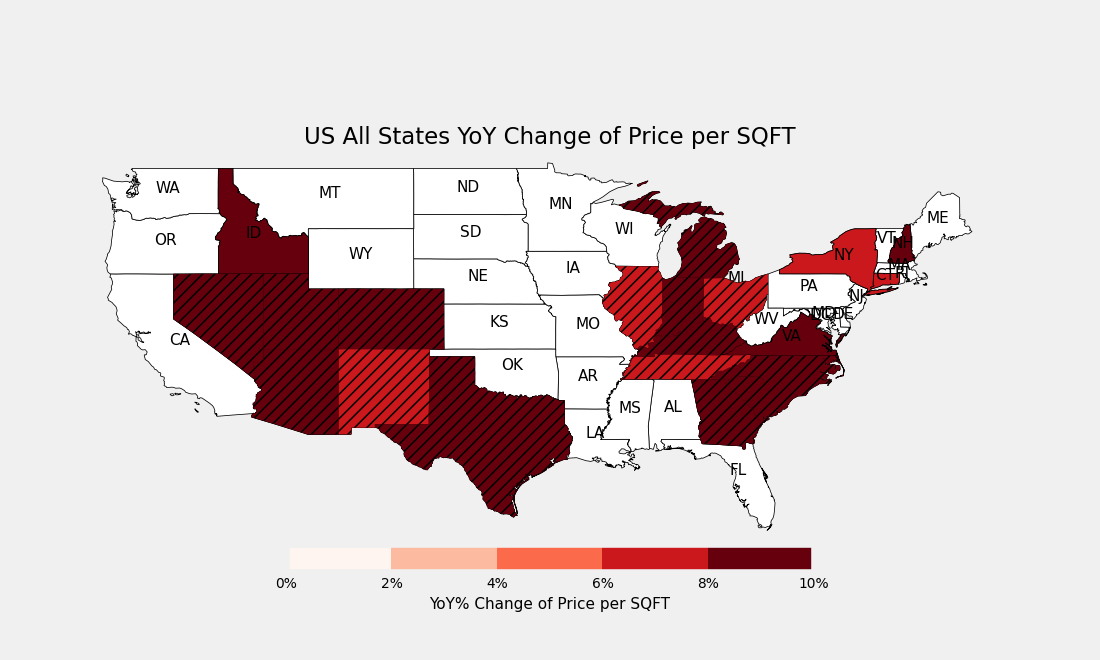

state is None
<class 'NoneType'> None


C:\pithon.shared\prod3\1.209.0\lib\site-packages\geopandas\plotting.py:681: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  UserWarning,
C:\pithon.shared\prod3\1.209.0\lib\site-packages\ipykernel_launcher.py:146: UserWarning: FixedFormatter should only be used together with FixedLocator


In [36]:
valueColumn = 'pctDiff_23vs22'
title = 'YoY Change of Price per SQFT'
textstr = '\n'.join(('Occupancy Code = 302', 
                     'Excluding Mobile Homes',
                     'State with >500 locations'))
textstr_title = ''.join(('Filters on Data'))
colorbar_ticks = ['0%', '2%', '4%', '6%', '8%', '10%']

plot_inputs = {'colorbar_label' : 'YoY% Change of Price per SQFT',
               'textstr': textstr,
               'textstr_title' :textstr_title,
               'title': title,
               'tfont': 15,
               'vmin':0,
               'vmax':0.1,
              'colorbar_ticks':colorbar_ticks}


plotFunction(deal_YoYPrice_Stategdf,valueColumn, graph_gdf=us_state_df ,# state='Florida',
             BenchmarkFlag=True, cmap ="Reds" ,**plot_inputs)


plt.savefig(r"Y:\Code\Data Quality\centralMutual_StateYoYChange_PriceperSQFTv3.png", transparent=True, format="png")

#### Testing

In [688]:
# valueColumn = 'pctDiff_23vs22'
# title = 'YoY Change of Price per SQFT'
# textstr = '\n'.join(('Occupancy Code = 302', 
#                      'Excluding Mobile Homes',
#                      'State with >500 locations'))
# textstr_title = ''.join(('Filters on Data'))

# plot_inputs = {'colorbar_label' : 'YoY% Change Price per SQFT',
#                'textstr': textstr,
#                'textstr_title' :textstr_title,
#                'title': title,
#                'tfont': 15,
#                'vmin':-0.1,
#                'vmax':0.1}


# plotFunction(notmorethan5_Stategdf,valueColumn, graph_gdf=us_state_df,# state='Texas',
#              BenchmarkFlag=True, **plot_inputs)


# plt.savefig(r"Y:\Code\Data Quality\Progressive_StateYoYChange_PriceperSQFT_10PctChange.png", transparent=True, format="png")

In [528]:
# valueColumn = 'pctDiff_23vs22'
# title = 'YoY Change of Price per SQFT'
# textstr = '\n'.join(('Occupancy Code = 302', 
#                      'Excluding Mobile Homes',
#                      'Counties with >100 locations'))

# textstr_title = ''.join(('Filters on Data'))
# plt_function(deal_YoYPrice_Countygdf,valueColumn,
#              State_or_County ='County',
#              Percentage_Flag=True,
#              colorbar_label='YoY% Change Price per SQFT',
#              textstr= textstr,
#              textstr_title = textstr_title,
#              title = title
#             )

# plt.savefig(r"Y:\Code\Data Quality\Progressive_CountyYoYChange_PriceperSQFT.png", transparent=True, format="png")

In [527]:
#deal_YoYPrice_Statedf['geometry'][1]
# #deal_YoYPrice_Statedf[deal_YoYPrice_Statedf['State']== 'Florida']['geometry'].iloc[0] #.bounds
# print(us_state_df[us_state_df['State'] == 'Florida']['geometry'].iloc[0].bounds)
# #xmin, ymin = lims[0], lims[1]
# # us_state_df[us_state_df['State'] == 'Florida'].plot()
# g = us_state_df[us_state_df['State'] == 'Florida'].geometry
# g.centroid, g.bounds, g.exterior.bounds, g.is_valid, len(g.interiors), \
# [i.bounds for i in g.interiors.iloc[0]], g.exterior.bounds
# fig2, ax2  = plt.subplots(figsize=(10,6))

# for i in g.interiors.iloc[0]:
#     ax2.plot(list(zip(*i.coords))[0], list(zip(*i.coords))[1])
# ax2.legend([str(i) for i in range(len(g.interiors.iloc[0]))])

# g.convex_hull.plot()
# fig2.show()

## Average Property Value

#### Data Pre Processing

In [782]:
# Extract State Level data from Average property Value Df
deal_YoYPropValue_Statedf = deal_YoYPropValue_df[deal_YoYPropValue_df['County'].isnull()]

# Drop the rows for which geometry column is null
deal_YoYPropValue_Statedf = deal_YoYPropValue_Statedf.dropna(subset=['geometry'])

# Create list of AveragePropertyValues for each state 
grouped_df = id_StatePropValue_df.groupby('State')['AveragePropertyValue'].apply(list).reset_index(name='Values')

# merge State data with grouped data
deal_YoYPropValue_Statedf = grouped_df.merge(deal_YoYPropValue_Statedf, on='State', how='right') #[['State', 'Values', 'BuildingvalueperSQFT_state', 'geometry']]

# replace the empty list with 0 if state do not have data 
deal_YoYPropValue_Statedf['Values'] = deal_YoYPropValue_Statedf['Values'].fillna(value=0)

# create percentile flag of Average property value using percentile_flag function
deal_YoYPropValue_Statedf['Percentile_Flag'] = deal_YoYPropValue_Statedf.apply(lambda x: percentile_flag(x.Values, x.AvgPropValue_2023), axis=1)

# Convert State level Pandas DataFrame to geoPandas DataFrame
deal_YoYPropValue_Statedf['geometry'] = gpd.GeoSeries.from_wkt(deal_YoYPropValue_Statedf['geometry'])
deal_YoYPropValue_Stategdf = gpd.GeoDataFrame(deal_YoYPropValue_Statedf, geometry='geometry')

deal_YoYPropValue_Stategdf = deal_YoYPropValue_Stategdf[deal_YoYPropValue_Stategdf['pctDiff_23vs22'] != 0]

In [783]:
# Extract County Level data from Average property Value Df
deal_YoYPropValue_Countydf = deal_YoYPropValue_df[~deal_YoYPropValue_df['County'].isnull()]

# Drop the rows for which geometry column is null
deal_YoYPropValue_Countydf = deal_YoYPropValue_Countydf.dropna(subset=['geometry'])

# Create list of AveragePropertyValues for each County 
grouped_df = id_CountyPropValue_df.groupby('County')['AveragePropertyValue'].apply(list).reset_index(name='Values')

# merge county data with grouped data
deal_YoYPropValue_Countydf = grouped_df.merge(deal_YoYPropValue_Countydf, on='County', how='right') #[['State', 'Values', 'BuildingvalueperSQFT_state', 'geometry']]

# replace the empty list with 0 if state do not have data 
deal_YoYPropValue_Countydf['Values'] = deal_YoYPropValue_Countydf['Values'].fillna(value=0)

# create percentile flag of Average property value using percentile_flag function
deal_YoYPropValue_Countydf['Percentile_Flag'] = deal_YoYPropValue_Countydf.apply(lambda x: percentile_flag(x.Values, x.AvgPropValue_2023), axis=1)

# Convert State level Pandas DataFrame to geoPandas DataFrame
deal_YoYPropValue_Countydf['geometry'] = gpd.GeoSeries.from_wkt(deal_YoYPropValue_Countydf['geometry'])
deal_YoYPropValue_Countygdf = gpd.GeoDataFrame(deal_YoYPropValue_Countydf, geometry='geometry')

deal_YoYPropValue_Countygdf = deal_YoYPropValue_Countygdf[deal_YoYPropValue_Countygdf['pctDiff_23vs22'] != 0]

# # County Level data
# county_df = avgPropValueFile[~avgPropValueFile['County'].isnull()]


# # Convert County level Pandas DataFrame to geoPandas DataFrame
# county_df['geometry'] = gpd.GeoSeries.from_wkt(county_df['geometry'])
# county_gdf = gpd.GeoDataFrame(county_df, geometry='geometry')

# county_gdf.shape

#### Plotting Charts

<IPython.core.display.Javascript object>


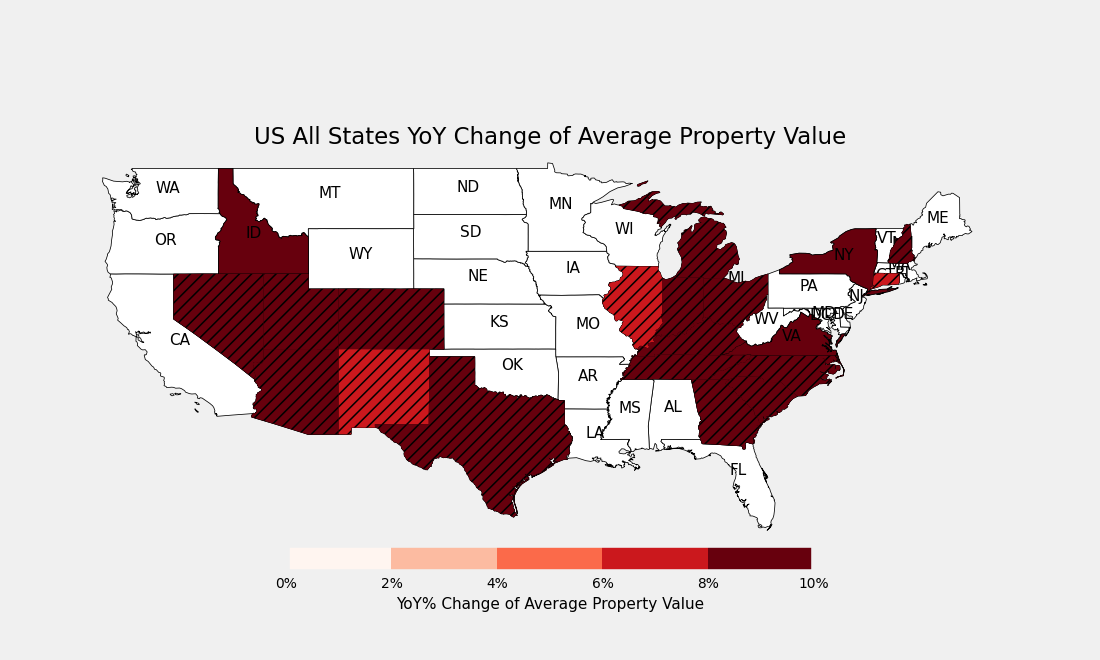

state is None
<class 'NoneType'> None


C:\pithon.shared\prod3\1.209.0\lib\site-packages\geopandas\plotting.py:681: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  UserWarning,
C:\pithon.shared\prod3\1.209.0\lib\site-packages\ipykernel_launcher.py:146: UserWarning: FixedFormatter should only be used together with FixedLocator


In [785]:
valueColumn = 'pctDiff_23vs22'
title = 'YoY Change of Average Property Value'
textstr = '\n'.join(('Occupancy Code = 302', 
                     'Excluding Mobile Homes',
                     'State with >500 locations'))
textstr_title = ''.join(('Filters on Data'))
colorbar_ticks = ['0%', '2%', '4%', '6%', '8%', '10%']

plot_inputs = {'colorbar_label' : 'YoY% Change of Average Property Value',
               'textstr': textstr,
               'textstr_title' :textstr_title,
               'title': title,
               'tfont': 15,
               'vmin':0,
               'vmax':0.1,
              'colorbar_ticks':colorbar_ticks}


plotFunction(deal_YoYPropValue_Stategdf,valueColumn, graph_gdf=us_state_df, #state='Florida',
             cmap='Reds',
             BenchmarkFlag=True, **plot_inputs)


plt.savefig(r"Y:\Code\Data Quality\FlPen_CountyYoYChange_AvgPropValuev2.png", transparent=True, format="png")

In [ ]:
deal_YoYPropValue_Stategdf[deal_YoYPropValue_Stategdf['pctDiff_23vs22'] < 0].sort_values(by=['pctDiff_23vs22']).State.unique()

In [390]:
valueColumn = 'pctDiff_23vs22'
title = 'State Level YoY% Change in Average Property Value'
textstr = '\n'.join(('Occupancy Code = 302', 
                     'Excluding Mobile Homes',
                     'State with >500 locations'))

textstr_title = ''.join(('Filters on Data'))
plt_function(deal_YoYPropValue_Stategdf,valueColumn,
             State_or_County ='State',
             Percentage_Flag=True,
             colorbar_label='YoY% Change in Average Property Value',
             textstr= textstr,
             textstr_title = textstr_title,title = title, tfont=13
            )

# plt.savefig(r"Y:\Code\Data Quality\Progressive_StateYoYChnage_AvgPropValue.png", transparent=True, format="png")

TypeError: plt_function() missing 2 required positional arguments: 'vmin' and 'vmax'

In [ ]:

## Find Out County for which percentage difference is more than 1%

# county_gdfBelow1 = county_gdf[county_gdf['PctDiff_23vs22'] > 1]

# county_gdfBelow1.head()

# county_gdf = county_gdf[county_gdf['LocCount23'] > 100]

# print(county_gdfBelow1.shape)

# county_gdfBelow1.sort_values(by=['PctDiff_23vs22'],ascending = False).head(30)

valueColumn = 'pctDiff_23vs22'
title = 'County Level YoY% Change in Average Property Value'
textstr = '\n'.join(('Occupancy Code = 302', 'Excluding Mobile Homes',
                     'Counties with >100 locations'))

plt_function(deal_YoYPropValue_Countygdf,
             valueColumn,
             State_or_County ='County',
             Percentage_Flag=True,
             colorbar_label='YoY% Change in Average Property Value',
             textstr= textstr,
             textstr_title = textstr_title,title = title
            ) #, cmap=cmap )

plt.savefig(r"Y:\Code\Data Quality\Progressive_CountyYoYChnage_AvgPropValue.png", transparent=True, format="png")

In [ ]:
deal_YoYPropValue_Countygdf[deal_YoYPropValue_Countygdf['pctDiff_23vs22'] < 0].County.unique()

In [ ]:
deal_YoYPropValue_Countygdf[deal_YoYPropValue_Countygdf['pctDiff_23vs22'] < 0][deal_YoYPropValue_Countygdf['State'] == 'California'].sort_values(by=['BuildingValue23'], ascending=True).County.unique()